# Imports

In [8]:
import spacy
import pandas as pd
from collections import defaultdict
from tqdm import tqdm  # Correct import

df = pd.read_csv('../../Data/2. IntermediateData/df_binarized_hard.csv')

# Testing on 1000 rows

In [9]:
# Initialize spaCy with optimizations
try:
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])
except OSError:
    print("Downloading spaCy model...")
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])

nlp.add_pipe("sentencizer")

# Take first 1000 rows with original index
sample_df = df.iloc[:1000].copy()

def analyze_with_progress(df_chunk):
    """Process DataFrame chunk with tqdm"""
    results = []
    # Create tqdm iterator explicitly
    tqdm_iterator = tqdm(df_chunk.iterrows(), total=len(df_chunk), desc="Analyzing dialogues")
    
    for _, row in tqdm_iterator:
        doc = nlp(row["text"])
        subjects = objects = 0
        
        for token in doc:
            # Female reference check
            is_female = (
                token.text.lower() in {"she", "her", "hers", "woman", "girl" } or
                (token.text.lower() == "i" and row["gender"] == "f")
            )
            
            if is_female:
                if token.dep_ in ("nsubj", "nsubjpass"):
                    subjects += 1
                elif token.dep_ in ("dobj", "iobj", "pobj"):
                    objects += 1
        
        results.append({"female_subjects": subjects, "female_objects": objects})
    
    return pd.DataFrame(results)

# Process with progress bar
print("🔍 Analyzing gender references in dialogues...")
result_df = analyze_with_progress(sample_df)

# Combine results
sample_df = pd.concat([sample_df, result_df], axis=1)

# Display results
print("\n📊 Results:")
print(f"Total female subjects: {sample_df['female_subjects'].sum()}")
print(f"Total female objects: {sample_df['female_objects'].sum()}\n")

print("By gender category:")
print(sample_df.groupby("gender")[["female_subjects", "female_objects"]].sum())

print("\n✅ Analysis complete!")

🔍 Analyzing gender references in dialogues...


Analyzing dialogues: 100%|██████████| 1000/1000 [00:01<00:00, 513.56it/s]



📊 Results:
Total female subjects: 199
Total female objects: 37

By gender category:
        female_subjects  female_objects
gender                                 
f                   166               3
m                    33              34

✅ Analysis complete!


In [10]:
sample_df

,utterance_id,conversation_id,text,speaker,movie_id,reply_to,speaker_id,character_name,movie_id.1,title,...,id,imdbid,bechdel_score,imdb_score,numVotes,runtimeMinutes,genres,oscar,female_subjects,female_objects
0,L1045,L1044,They do not!,u0,m0,L1044,u0,BIANCA,m0,10 things i hate about you,...,374,147800,1,7.4,424659,97,"Comedy,Drama,Romance",0,0,0
1,L1044,L1044,They do to!,u2,m0,NaN,u2,CAMERON,m0,10 things i hate about you,...,374,147800,1,7.4,424659,97,"Comedy,Drama,Romance",0,0,0
2,L985,L984,I hope so.,u0,m0,L984,u0,BIANCA,m0,10 things i hate about you,...,374,147800,1,7.4,424659,97,"Comedy,Drama,Romance",0,1,0
3,L984,L984,She okay?,u2,m0,NaN,u2,CAMERON,m0,10 things i hate about you,...,374,147800,1,7.4,424659,97,"Comedy,Drama,Romance",0,1,0
4,L925,L924,Let's go.,u0,m0,L924,u0,BIANCA,m0,10 things i hate about you,...,374,147800,1,7.4,424659,97,"Comedy,Drama,Romance",0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,L5084,L5083,You stay with me...,u67,m4,L5083,u67,CATES,m4,48 hrs.,...,5355,83511,0,6.9,90341,96,"Action,Comedy,Crime",0,0,0
996,L5083,L5083,Bullshit. Then i'm staying with the money.,u71,m4,NaN,u71,HAMMOND,m4,48 hrs.,...,5355,83511,0,6.9,90341,96,"Action,Comedy,Crime",0,0,0
997,L5077,L5076,Right. if you ever switch from armed robbery t...,u67,m4,L5076,u67,CATES,m4,48 hrs.,...,5355,83511,0,6.9,90341,96,"Action,Comedy,Crime",0,0,0
998,L5076,L5076,"That was in style a couple years back, man.",u71,m4,NaN,u71,HAMMOND,m4,48 hrs.,...,5355,83511,0,6.9,90341,96,"Action,Comedy,Crime",0,0,0


# Running on whole dataset

In [13]:
import spacy
import pandas as pd
from tqdm import tqdm
from collections import defaultdict

# Initialize spaCy with optimizations
try:
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])
except OSError:
    print("Downloading spaCy model...")
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])

nlp.add_pipe("sentencizer")

# ===== EXPANDED GENDERED REFERENCES DICTIONARY =====
GENDERED_TERMS = {
    # Female references
    "female": {
        "pronouns": {"she", "her", "hers", "herself"},
        "nouns": {"woman", "women", "girl", "girls", "lady", "ladies", "female", "females", "mother", "daughter", "sister", "actress"}
    },
    # Male references
    "male": {
        "pronouns": {"he", "him", "his", "himself"},
        "nouns": {"man", "men", "boy", "boys", "gentleman", "gentlemen", "male", "males", "father", "son", "brother", "actor"}
    },
    # Neutral/inclusive references
    "neutral": {
        "pronouns": {"they", "them", "their", "theirs", "themself", "themselves"},
        "nouns": {"person", "people", "child", "children", "individual", "actor", "doctor"}  # Gender-neutral professional terms
    }
}

# Take first 1000 rows for demonstration (replace with full_df for complete analysis)
sample_df = df.copy()

def analyze_with_progress(df_chunk):
    """Process DataFrame with expanded gender analysis"""
    results = []
    tqdm_iterator = tqdm(df_chunk.iterrows(), total=len(df_chunk), desc="Analyzing dialogues")
    
    for _, row in tqdm_iterator:
        doc = nlp(row["text"])
        counts = defaultdict(int)
        
        for token in doc:
            # Check all gender categories
            for gender_category, terms in GENDERED_TERMS.items():
                # Check pronouns and nouns
                if (token.text.lower() in terms["pronouns"]) or \
                   (token.text.lower() in terms["nouns"]) or \
                   (token.text.lower() == "i" and row["gender"].lower() == gender_category[0]):  # Handle "I" based on speaker gender
                    
                    # Subject/object analysis
                    if token.dep_ in ("nsubj", "nsubjpass"):
                        counts[f"{gender_category}_subjects"] += 1
                    elif token.dep_ in ("dobj", "iobj", "pobj"):
                        counts[f"{gender_category}_objects"] += 1
        
        results.append(counts)
    
    return pd.DataFrame(results)

# Process with progress bar
print("🔍 Analyzing expanded gender references...")
result_df = analyze_with_progress(sample_df)

# Combine results (fill NaN with 0 for missing categories)
sample_df = pd.concat([sample_df, result_df.fillna(0)], axis=1)

# Display results
print("\n📊 Results by Gender Category:")
gender_categories = ["female", "male", "neutral"]
for category in gender_categories:
    print(f"\n{category.capitalize()} References:")
    print(f"Subjects: {sample_df[f'{category}_subjects'].sum():>6}")
    print(f"Objects:  {sample_df[f'{category}_objects'].sum():>6}")

print("\n📈 Subject/Object Ratios:")
for category in gender_categories:
    total = sample_df[[f'{category}_subjects', f'{category}_objects']].sum().sum()
    if total > 0:
        ratio = sample_df[f'{category}_subjects'].sum() / total
        print(f"{category.capitalize()}: {ratio:.1%} subject references")

print("\n✅ Analysis complete!")

🔍 Analyzing expanded gender references...


Analyzing dialogues: 100%|██████████| 137062/137062 [04:58<00:00, 459.80it/s]



📊 Results by Gender Category:

Female References:
Subjects: 29025.0
Objects:  3743.0

Male References:
Subjects: 55602.0
Objects:  5942.0

Neutral References:
Subjects: 8607.0
Objects:  3533.0

📈 Subject/Object Ratios:
Female: 88.6% subject references
Male: 90.3% subject references
Neutral: 70.9% subject references

✅ Analysis complete!


In [18]:
import scipy.stats as stats
import numpy as np
from statsmodels.stats.proportion import proportions_ztest  # Correct import

# Your results
counts = np.array([29025, 55602])    # Female and male subjects
nobs = np.array([29025+3743, 55602+5942])  # Total references per gender

# 1. Two-proportion z-test
z_score, p_value = proportions_ztest(counts, nobs)
print(f"Female vs Male Subject Ratios:")
print(f"Z = {z_score:.2f}, p = {p_value:.20f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

# 2. Effect size (Cohen's h)
female_ratio = counts[0]/nobs[0]
male_ratio = counts[1]/nobs[1]
h = 2*(np.arcsin(np.sqrt(female_ratio)) - np.arcsin(np.sqrt(male_ratio)))
print(f"Effect Size (Cohen's h): {abs(h):.3f}")

# 3. Install statsmodels if needed
try:
    from statsmodels.stats.proportion import proportions_ztest
except ImportError:
    print("\nInstalling required package...")
    import sys
    !{sys.executable} -m pip install statsmodels
    from statsmodels.stats.proportion import proportions_ztest

Female vs Male Subject Ratios:
Z = -8.52, p = 0.00000000000000001650 ***
Effect Size (Cohen's h): 0.058


In [14]:
sample_df

,utterance_id,conversation_id,text,speaker,movie_id,reply_to,speaker_id,character_name,movie_id.1,title,...,numVotes,runtimeMinutes,genres,oscar,neutral_subjects,female_subjects,male_subjects,male_objects,neutral_objects,female_objects
0,L1045,L1044,They do not!,u0,m0,L1044,u0,BIANCA,m0,10 things i hate about you,...,424659,97,"Comedy,Drama,Romance",0,1.0,0.0,0.0,0.0,0.0,0.0
1,L1044,L1044,They do to!,u2,m0,NaN,u2,CAMERON,m0,10 things i hate about you,...,424659,97,"Comedy,Drama,Romance",0,1.0,0.0,0.0,0.0,0.0,0.0
2,L985,L984,I hope so.,u0,m0,L984,u0,BIANCA,m0,10 things i hate about you,...,424659,97,"Comedy,Drama,Romance",0,0.0,1.0,0.0,0.0,0.0,0.0
3,L984,L984,She okay?,u2,m0,NaN,u2,CAMERON,m0,10 things i hate about you,...,424659,97,"Comedy,Drama,Romance",0,0.0,1.0,0.0,0.0,0.0,0.0
4,L925,L924,Let's go.,u0,m0,L924,u0,BIANCA,m0,10 things i hate about you,...,424659,97,"Comedy,Drama,Romance",0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137057,L665991,L665987,"I'm sorry, sir. We only seat by reservation.",u9021,m615,L665990,u9021,MAITRE D',m615,young frankenstein,...,176404,106,Comedy,0,0.0,1.0,0.0,0.0,0.0,0.0
137058,L665990,L665987,Food!!,u9023,m615,L665989,u9023,MONSTER,m615,young frankenstein,...,176404,106,Comedy,0,0.0,0.0,0.0,0.0,0.0,0.0
137059,L665989,L665987,Do you have a reservation?,u9021,m615,L665988,u9021,MAITRE D',m615,young frankenstein,...,176404,106,Comedy,0,0.0,0.0,0.0,0.0,0.0,0.0
137060,L665988,L665987,Food!,u9023,m615,L665987,u9023,MONSTER,m615,young frankenstein,...,176404,106,Comedy,0,0.0,0.0,0.0,0.0,0.0,0.0


# DF_Hard

In [48]:
df = pd.read_csv('../../Data/2. IntermediateData/df_binarized_hard.csv')
# Initialize spaCy
try:
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])
except OSError:
    print("Downloading spaCy model...")
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])

nlp.add_pipe("sentencizer")

# Expanded gendered references dictionary
GENDERED_TERMS = {
    "female": {
        "pronouns": {"she", "her", "hers", "herself"},
        "nouns": {"woman", "women", "girl", "girls", "lady", "ladies", "female", 
                 "females", "mother", "daughter", "sister", "actress"}
    },
    "male": {
        "pronouns": {"he", "him", "his", "himself"},
        "nouns": {"man", "men", "boy", "boys", "gentleman", "gentlemen", "male",
                 "males", "father", "son", "brother", "actor"}
    },
    "neutral": {
        "pronouns": {"they", "them", "their", "theirs", "themself", "themselves"},
        "nouns": {"person", "people", "child", "children", "individual"}
    }
}

# Split dataset
bechdel_1 = df[df['bechdel_score'] == 1].copy()
bechdel_0 = df[df['bechdel_score'] == 0].copy()

def analyze_dataset(df_chunk):
    """Process DataFrame with gender analysis"""
    results = []
    for _, row in tqdm(df_chunk.iterrows(), total=len(df_chunk), desc="Analyzing"):
        doc = nlp(row["text"])
        counts = defaultdict(int)
        
        for token in doc:
            for gender_category, terms in GENDERED_TERMS.items():
                if (token.text.lower() in terms["pronouns"]) or \
                   (token.text.lower() in terms["nouns"]) or \
                   (token.text.lower() == "i" and row["gender"].lower() == gender_category[0]):
                    
                    if token.dep_ in ("nsubj", "nsubjpass"):
                        counts[f"{gender_category}_subjects"] += 1
                    elif token.dep_ in ("dobj", "iobj", "pobj"):
                        counts[f"{gender_category}_objects"] += 1
        
        results.append(counts)
    return pd.concat([df_chunk, pd.DataFrame(results).fillna(0)], axis=1)

# Analyze both datasets
print("🔍 Analyzing Bechdel-passing films (score=1)...")
bechdel_1 = analyze_dataset(bechdel_1)

print("\n🔍 Analyzing non-Bechdel-passing films (score=0)...")
bechdel_0 = analyze_dataset(bechdel_0)

🔍 Analyzing Bechdel-passing films (score=1)...


Analyzing: 100%|██████████| 69402/69402 [02:00<00:00, 578.11it/s]



🔍 Analyzing non-Bechdel-passing films (score=0)...


Analyzing: 100%|██████████| 67660/67660 [01:55<00:00, 586.54it/s]


In [49]:
# Statistical comparison functions
def compare_results(df1, df2, category):
    """Compare subject ratios between two datasets"""
    subj1 = df1[f"{category}_subjects"].sum()
    obj1 = df1[f"{category}_objects"].sum()
    subj2 = df2[f"{category}_subjects"].sum()
    obj2 = df2[f"{category}_objects"].sum()
    
    ratio1 = subj1/(subj1+obj1) if (subj1+obj1) > 0 else 0
    ratio2 = subj2/(subj2+obj2) if (subj2+obj2) > 0 else 0
    
    z, p = proportions_ztest(
        [subj1, subj2],
        [subj1+obj1, subj2+obj2]
    )
    
    h = 2*(np.arcsin(np.sqrt(ratio1)) - np.arcsin(np.sqrt(ratio2)))
    
    print(f"\n{category.upper()} COMPARISON:")
    print(f"Bechdel 1: {ratio1:.1%} subjects | Bechdel 0: {ratio2:.1%} subjects")
    print(f"Z = {z:.2f}, p = {p:.20f} {'***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'}")
    print(f"Effect size (h): {abs(h):.3f}")

# Display results and comparisons
print("\n📊 BECHDEL 1 RESULTS:")
for category in GENDERED_TERMS:
    total = bechdel_1[f"{category}_subjects"].sum() + bechdel_1[f"{category}_objects"].sum()
    ratio = bechdel_1[f"{category}_subjects"].sum() / total if total > 0 else 0
    print(f"{category.capitalize()}: Subjects={bechdel_1[f'{category}_subjects'].sum():,} | Objects={bechdel_1[f'{category}_objects'].sum():,} | Ratio={ratio:.1%}")

print("\n📊 BECHDEL 0 RESULTS:")
for category in GENDERED_TERMS:
    total = bechdel_0[f"{category}_subjects"].sum() + bechdel_0[f"{category}_objects"].sum()
    ratio = bechdel_0[f"{category}_subjects"].sum() / total if total > 0 else 0
    print(f"{category.capitalize()}: Subjects={bechdel_0[f'{category}_subjects'].sum():,} | Objects={bechdel_0[f'{category}_objects'].sum():,} | Ratio={ratio:.1%}")

# Statistical comparisons
for category in GENDERED_TERMS:
    compare_results(bechdel_1, bechdel_0, category)

print("\n✅ Analysis complete!")


📊 BECHDEL 1 RESULTS:
Female: Subjects=18,590.0 | Objects=2,181.0 | Ratio=89.5%
Male: Subjects=25,440.0 | Objects=2,832.0 | Ratio=90.0%
Neutral: Subjects=4,274.0 | Objects=1,804.0 | Ratio=70.3%

📊 BECHDEL 0 RESULTS:
Female: Subjects=10,435.0 | Objects=1,562.0 | Ratio=87.0%
Male: Subjects=30,162.0 | Objects=3,110.0 | Ratio=90.7%
Neutral: Subjects=4,285.0 | Objects=1,636.0 | Ratio=72.4%

FEMALE COMPARISON:
Bechdel 1: 89.5% subjects | Bechdel 0: 87.0% subjects
Z = 6.91, p = 0.00000000000492011321 ***
Effect size (h): 0.078

MALE COMPARISON:
Bechdel 1: 90.0% subjects | Bechdel 0: 90.7% subjects
Z = -2.80, p = 0.00505208108695867023 **
Effect size (h): 0.023

NEUTRAL COMPARISON:
Bechdel 1: 70.3% subjects | Bechdel 0: 72.4% subjects
Z = -2.48, p = 0.01302589681188344450 *
Effect size (h): 0.045

✅ Analysis complete!


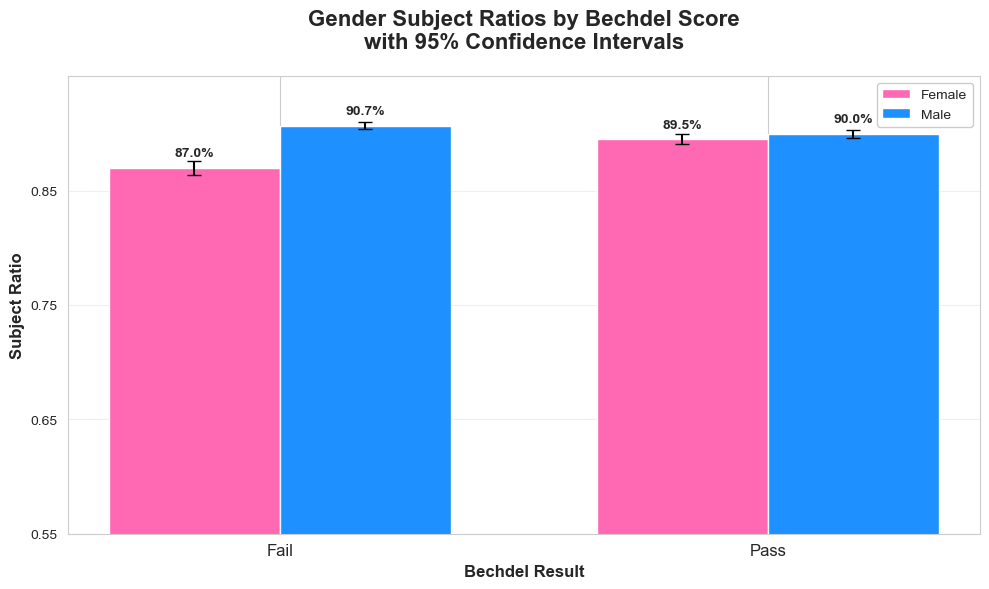

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportion_confint

# Create the DataFrame (Bechdel 0 first, then 1)
data = {
    'bechdel_score': [0, 0, 1, 1],  # 0 comes first
    'gender': ['female', 'male', 'female', 'male'],
    'subjects': [10435.0, 30162.0, 18590.0, 25440.0],
    'objects': [1562.0, 3110.0, 2181.0, 2832.0]
}

df = pd.DataFrame(data)

# Calculate ratios and confidence intervals
df['ratio'] = df['subjects'] / (df['subjects'] + df['objects'])
df['ci_low'], df['ci_high'] = proportion_confint(
    count=df['subjects'],
    nobs=df['subjects'] + df['objects'],
    alpha=0.05,
    method='wilson'
)

# Visualization with tight spacing
plt.figure(figsize=(10, 6))
colors = {'female': '#FF69B4', 'male': '#1E90FF'}
bar_width = 0.35  # Wider bars for tighter grouping
positions = np.array([0, 1])  # 0 and 1 positions

for i, gender in enumerate(['female', 'male']):
    gender_data = df[df['gender'] == gender]
    offset = (i - 0.5) * bar_width  # Center the bars
    
    plt.bar(
        positions + offset,
        gender_data['ratio'],
        width=bar_width,
        color=colors[gender],
        label=gender.capitalize(),
        yerr=[
            gender_data['ratio'] - gender_data['ci_low'],
            gender_data['ci_high'] - gender_data['ratio']
        ],
        capsize=5
    )
    
    # Add ratio labels
    for j, (ratio, score) in enumerate(zip(gender_data['ratio'], gender_data['bechdel_score'])):
        plt.text(
            positions[j] + offset,
            ratio + 0.01,  # Slightly lower position
            f"{ratio:.1%}",
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

# Formatting
plt.xticks(positions, ['Fail', 'Pass'], fontsize=12)
plt.yticks(np.arange(0.55, 0.95, 0.1), fontsize=10)
plt.ylim(0.55, 0.95)
plt.ylabel('Subject Ratio', fontsize=12, fontweight='bold')
plt.xlabel("Bechdel Result", fontsize=12, fontweight='bold')
plt.title('Gender Subject Ratios by Bechdel Score\nwith 95% Confidence Intervals', fontsize=16, pad=20, weight='bold')
plt.legend(loc='upper right', framealpha=1)
plt.grid(True, axis='y', alpha=0.3)

# Adjust layout
plt.subplots_adjust(bottom=0.15)
plt.tight_layout()
plt.show()

# DF_Medium

In [29]:
df = pd.read_csv('../../Data/2. IntermediateData/df_binarized_medium.csv')

In [30]:
# Initialize spaCy
try:
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])
except OSError:
    print("Downloading spaCy model...")
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])

nlp.add_pipe("sentencizer")

# Expanded gendered references dictionary
GENDERED_TERMS = {
    "female": {
        "pronouns": {"she", "her", "hers", "herself"},
        "nouns": {"woman", "women", "girl", "girls", "lady", "ladies", "female", 
                 "females", "mother", "daughter", "sister", "actress"}
    },
    "male": {
        "pronouns": {"he", "him", "his", "himself"},
        "nouns": {"man", "men", "boy", "boys", "gentleman", "gentlemen", "male",
                 "males", "father", "son", "brother", "actor"}
    },
    "neutral": {
        "pronouns": {"they", "them", "their", "theirs", "themself", "themselves"},
        "nouns": {"person", "people", "child", "children", "individual"}
    }
}

# Split dataset
bechdel_1 = df[df['bechdel_score'] == 1].copy()
bechdel_0 = df[df['bechdel_score'] == 0].copy()

def analyze_dataset(df_chunk):
    """Process DataFrame with gender analysis"""
    results = []
    for _, row in tqdm(df_chunk.iterrows(), total=len(df_chunk), desc="Analyzing"):
        doc = nlp(row["text"])
        counts = defaultdict(int)
        
        for token in doc:
            for gender_category, terms in GENDERED_TERMS.items():
                if (token.text.lower() in terms["pronouns"]) or \
                   (token.text.lower() in terms["nouns"]) or \
                   (token.text.lower() == "i" and row["gender"].lower() == gender_category[0]):
                    
                    if token.dep_ in ("nsubj", "nsubjpass"):
                        counts[f"{gender_category}_subjects"] += 1
                    elif token.dep_ in ("dobj", "iobj", "pobj"):
                        counts[f"{gender_category}_objects"] += 1
        
        results.append(counts)
    return pd.concat([df_chunk, pd.DataFrame(results).fillna(0)], axis=1)

# Analyze both datasets
print("🔍 Analyzing Bechdel-passing films (score=1)...")
bechdel_1 = analyze_dataset(bechdel_1)

print("\n🔍 Analyzing non-Bechdel-passing films (score=0)...")
bechdel_0 = analyze_dataset(bechdel_0)
# Statistical comparison functions

def compare_results(df1, df2, category):
    """Compare subject ratios between two datasets"""
    subj1 = df1[f"{category}_subjects"].sum()
    obj1 = df1[f"{category}_objects"].sum()
    subj2 = df2[f"{category}_subjects"].sum()
    obj2 = df2[f"{category}_objects"].sum()
    
    ratio1 = subj1/(subj1+obj1) if (subj1+obj1) > 0 else 0
    ratio2 = subj2/(subj2+obj2) if (subj2+obj2) > 0 else 0
    
    z, p = proportions_ztest(
        [subj1, subj2],
        [subj1+obj1, subj2+obj2]
    )
    
    h = 2*(np.arcsin(np.sqrt(ratio1)) - np.arcsin(np.sqrt(ratio2)))
    
    print(f"\n{category.upper()} COMPARISON:")
    print(f"Bechdel 1: {ratio1:.1%} subjects | Bechdel 0: {ratio2:.1%} subjects")
    print(f"Z = {z:.2f}, p = {p:.20f} {'***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'}")
    print(f"Effect size (h): {abs(h):.3f}")

# Display results and comparisons
print("\n📊 BECHDEL 1 RESULTS:")
for category in GENDERED_TERMS:
    total = bechdel_1[f"{category}_subjects"].sum() + bechdel_1[f"{category}_objects"].sum()
    ratio = bechdel_1[f"{category}_subjects"].sum() / total if total > 0 else 0
    print(f"{category.capitalize()}: Subjects={bechdel_1[f'{category}_subjects'].sum():,} | Objects={bechdel_1[f'{category}_objects'].sum():,} | Ratio={ratio:.1%}")

print("\n📊 BECHDEL 0 RESULTS:")
for category in GENDERED_TERMS:
    total = bechdel_0[f"{category}_subjects"].sum() + bechdel_0[f"{category}_objects"].sum()
    ratio = bechdel_0[f"{category}_subjects"].sum() / total if total > 0 else 0
    print(f"{category.capitalize()}: Subjects={bechdel_0[f'{category}_subjects'].sum():,} | Objects={bechdel_0[f'{category}_objects'].sum():,} | Ratio={ratio:.1%}")

# Statistical comparisons
for category in GENDERED_TERMS:
    compare_results(bechdel_1, bechdel_0, category)

print("\n✅ Analysis complete!")

🔍 Analyzing Bechdel-passing films (score=1)...


Analyzing: 100%|██████████| 90058/90058 [02:35<00:00, 579.69it/s]



🔍 Analyzing non-Bechdel-passing films (score=0)...


Analyzing: 100%|██████████| 47004/47004 [01:25<00:00, 550.16it/s]



📊 BECHDEL 1 RESULTS:
Female: Subjects=22,556.0 | Objects=2,648.0 | Ratio=89.5%
Male: Subjects=34,110.0 | Objects=3,681.0 | Ratio=90.3%
Neutral: Subjects=5,517.0 | Objects=2,342.0 | Ratio=70.2%

📊 BECHDEL 0 RESULTS:
Female: Subjects=6,469.0 | Objects=1,095.0 | Ratio=85.5%
Male: Subjects=21,492.0 | Objects=2,261.0 | Ratio=90.5%
Neutral: Subjects=3,042.0 | Objects=1,098.0 | Ratio=73.5%

FEMALE COMPARISON:
Bechdel 1: 89.5% subjects | Bechdel 0: 85.5% subjects
Z = 9.52, p = 0.00000000000000000000 ***
Effect size (h): 0.120

MALE COMPARISON:
Bechdel 1: 90.3% subjects | Bechdel 0: 90.5% subjects
Z = -0.91, p = 0.36481532029256913408 ns
Effect size (h): 0.008

NEUTRAL COMPARISON:
Bechdel 1: 70.2% subjects | Bechdel 0: 73.5% subjects
Z = -3.78, p = 0.00015988215803527275 ***
Effect size (h): 0.073

✅ Analysis complete!


# DF_Easy

In [24]:
df = pd.read_csv('../../Data/2. IntermediateData/df_binarized_easy.csv')
# Initialize spaCy
try:
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])
except OSError:
    print("Downloading spaCy model...")
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])

nlp.add_pipe("sentencizer")

# Expanded gendered references dictionary
GENDERED_TERMS = {
    "female": {
        "pronouns": {"she", "her", "hers", "herself"},
        "nouns": {"woman", "women", "girl", "girls", "lady", "ladies", "female", 
                 "females", "mother", "daughter", "sister", "actress"}
    },
    "male": {
        "pronouns": {"he", "him", "his", "himself"},
        "nouns": {"man", "men", "boy", "boys", "gentleman", "gentlemen", "male",
                 "males", "father", "son", "brother", "actor"}
    },
    "neutral": {
        "pronouns": {"they", "them", "their", "theirs", "themself", "themselves"},
        "nouns": {"person", "people", "child", "children", "individual"}
    }
}

# Split dataset
bechdel_1 = df[df['bechdel_score'] == 1].copy()
bechdel_0 = df[df['bechdel_score'] == 0].copy()

def analyze_dataset(df_chunk):
    """Process DataFrame with gender analysis"""
    results = []
    for _, row in tqdm(df_chunk.iterrows(), total=len(df_chunk), desc="Analyzing"):
        doc = nlp(row["text"])
        counts = defaultdict(int)
        
        for token in doc:
            for gender_category, terms in GENDERED_TERMS.items():
                if (token.text.lower() in terms["pronouns"]) or \
                   (token.text.lower() in terms["nouns"]) or \
                   (token.text.lower() == "i" and row["gender"].lower() == gender_category[0]):
                    
                    if token.dep_ in ("nsubj", "nsubjpass"):
                        counts[f"{gender_category}_subjects"] += 1
                    elif token.dep_ in ("dobj", "iobj", "pobj"):
                        counts[f"{gender_category}_objects"] += 1
        
        results.append(counts)
    return pd.concat([df_chunk, pd.DataFrame(results).fillna(0)], axis=1)

# Analyze both datasets
print("🔍 Analyzing Bechdel-passing films (score=1)...")
bechdel_1 = analyze_dataset(bechdel_1)

print("\n🔍 Analyzing non-Bechdel-passing films (score=0)...")
bechdel_0 = analyze_dataset(bechdel_0)
# Statistical comparison functions

def compare_results(df1, df2, category):
    """Compare subject ratios between two datasets"""
    subj1 = df1[f"{category}_subjects"].sum()
    obj1 = df1[f"{category}_objects"].sum()
    subj2 = df2[f"{category}_subjects"].sum()
    obj2 = df2[f"{category}_objects"].sum()
    
    ratio1 = subj1/(subj1+obj1) if (subj1+obj1) > 0 else 0
    ratio2 = subj2/(subj2+obj2) if (subj2+obj2) > 0 else 0
    
    z, p = proportions_ztest(
        [subj1, subj2],
        [subj1+obj1, subj2+obj2]
    )
    
    h = 2*(np.arcsin(np.sqrt(ratio1)) - np.arcsin(np.sqrt(ratio2)))
    
    print(f"\n{category.upper()} COMPARISON:")
    print(f"Bechdel 1: {ratio1:.1%} subjects | Bechdel 0: {ratio2:.1%} subjects")
    print(f"Z = {z:.2f}, p = {p:.10f} {'***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'}")
    print(f"Effect size (h): {abs(h):.3f}")

# Display results and comparisons
print("\n📊 BECHDEL 1 RESULTS:")
for category in GENDERED_TERMS:
    total = bechdel_1[f"{category}_subjects"].sum() + bechdel_1[f"{category}_objects"].sum()
    ratio = bechdel_1[f"{category}_subjects"].sum() / total if total > 0 else 0
    print(f"{category.capitalize()}: Subjects={bechdel_1[f'{category}_subjects'].sum():,} | Objects={bechdel_1[f'{category}_objects'].sum():,} | Ratio={ratio:.1%}")

print("\n📊 BECHDEL 0 RESULTS:")
for category in GENDERED_TERMS:
    total = bechdel_0[f"{category}_subjects"].sum() + bechdel_0[f"{category}_objects"].sum()
    ratio = bechdel_0[f"{category}_subjects"].sum() / total if total > 0 else 0
    print(f"{category.capitalize()}: Subjects={bechdel_0[f'{category}_subjects'].sum():,} | Objects={bechdel_0[f'{category}_objects'].sum():,} | Ratio={ratio:.1%}")

# Statistical comparisons
for category in GENDERED_TERMS:
    compare_results(bechdel_1, bechdel_0, category)

print("\n✅ Analysis complete!")

🔍 Analyzing Bechdel-passing films (score=1)...


Analyzing: 100%|██████████| 126961/126961 [03:36<00:00, 585.12it/s]



🔍 Analyzing non-Bechdel-passing films (score=0)...


Analyzing: 100%|██████████| 10101/10101 [00:17<00:00, 566.66it/s]


📊 BECHDEL 1 RESULTS:
Female: Subjects=28,091.0 | Objects=3,596.0 | Ratio=88.7%
Male: Subjects=50,699.0 | Objects=5,447.0 | Ratio=90.3%
Neutral: Subjects=7,740.0 | Objects=3,173.0 | Ratio=70.9%

📊 BECHDEL 0 RESULTS:
Female: Subjects=934.0 | Objects=147.0 | Ratio=86.4%
Male: Subjects=4,903.0 | Objects=495.0 | Ratio=90.8%
Neutral: Subjects=819.0 | Objects=267.0 | Ratio=75.4%

FEMALE COMPARISON:
Bechdel 1: 88.7% subjects | Bechdel 0: 86.4% subjects
Z = 2.29, p = 0.0221951928 *
Effect size (h): 0.068

MALE COMPARISON:
Bechdel 1: 90.3% subjects | Bechdel 0: 90.8% subjects
Z = -1.26, p = 0.2066941918 ns
Effect size (h): 0.018

NEUTRAL COMPARISON:
Bechdel 1: 70.9% subjects | Bechdel 0: 75.4% subjects
Z = -3.12, p = 0.0018067829 **
Effect size (h): 0.101

✅ Analysis complete!


# By original dataset

🔍 Analyzing Bechdel score 0 films...


Analyzing: 100%|██████████| 10101/10101 [00:17<00:00, 561.85it/s]


🔍 Analyzing Bechdel score 1 films...


Analyzing: 100%|██████████| 36903/36903 [01:04<00:00, 572.03it/s]


🔍 Analyzing Bechdel score 2 films...


Analyzing: 100%|██████████| 20656/20656 [00:37<00:00, 554.79it/s]


🔍 Analyzing Bechdel score 3 films...


Analyzing: 100%|██████████| 69402/69402 [02:01<00:00, 570.22it/s]


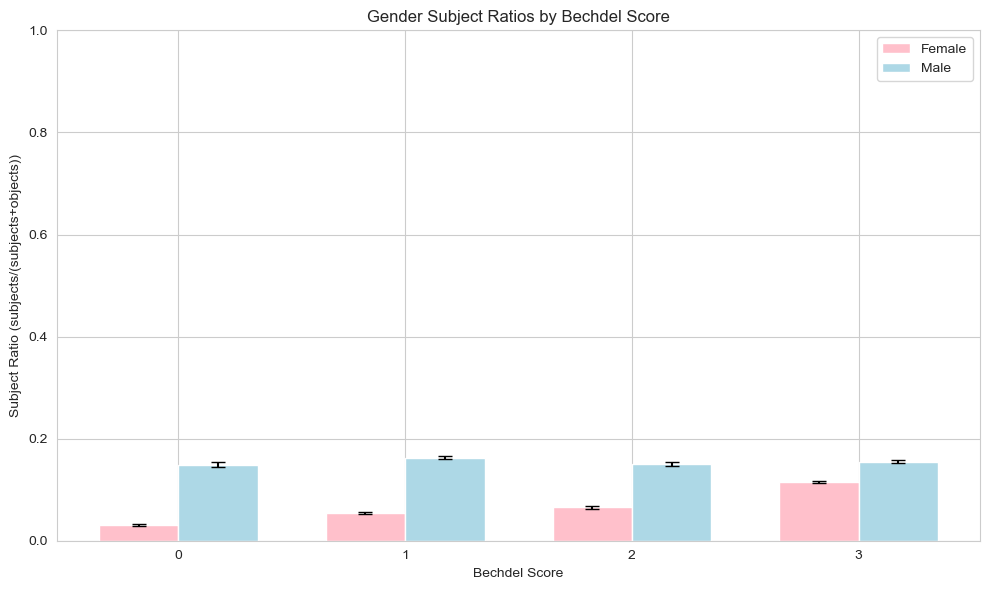


T-TEST RESULTS FOR FEMALE RATIOS:
Bechdel 0 vs 1: t = -15.45, p = 0.0000
Bechdel 0 vs 2: t = -19.73, p = 0.0000
Bechdel 0 vs 3: t = -54.56, p = 0.0000
Bechdel 1 vs 2: t = -7.51, p = 0.0000
Bechdel 1 vs 3: t = -46.96, p = 0.0000
Bechdel 2 vs 3: t = -31.13, p = 0.0000

MIXED EFFECTS MODEL:


TypeError: '<' not supported between instances of 'float' and 'str'

In [ ]:
df = pd.read_csv('../../Data/2. IntermediateData/df_clean_original.csv')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import defaultdict
import spacy
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Initialize spaCy (same as before)
try:
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])
except OSError:
    print("Downloading spaCy model...")
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])

nlp.add_pipe("sentencizer")

# Expanded gendered references dictionary (same as before)
GENDERED_TERMS = {
    "female": {
        "pronouns": {"she", "her", "hers", "herself"},
        "nouns": {"woman", "women", "girl", "girls", "lady", "ladies", "female", 
                 "females", "mother", "daughter", "sister", "actress"}
    },
    "male": {
        "pronouns": {"he", "him", "his", "himself"},
        "nouns": {"man", "men", "boy", "boys", "gentleman", "gentlemen", "male",
                 "males", "father", "son", "brother", "actor"}
    },
    "neutral": {
        "pronouns": {"they", "them", "their", "theirs", "themself", "themselves"},
        "nouns": {"person", "people", "child", "children", "individual"}
    }
}

# Split dataset by all Bechdel scores
bechdel_groups = {score: df[df['bechdel_score'] == score].copy() for score in [0, 1, 2, 3]}

def analyze_dataset(df_chunk):
    """Process DataFrame with gender analysis (same as before)"""
    results = []
    for _, row in tqdm(df_chunk.iterrows(), total=len(df_chunk), desc="Analyzing"):
        doc = nlp(row["text"])
        counts = defaultdict(int)
        
        for token in doc:
            for gender_category, terms in GENDERED_TERMS.items():
                if (token.text.lower() in terms["pronouns"]) or \
                   (token.text.lower() in terms["nouns"]) or \
                   (token.text.lower() == "i" and row["gender"].lower() == gender_category[0]):
                    
                    if token.dep_ in ("nsubj", "nsubjpass"):
                        counts[f"{gender_category}_subjects"] += 1
                    elif token.dep_ in ("dobj", "iobj", "pobj"):
                        counts[f"{gender_category}_objects"] += 1
        
        results.append(counts)
    return pd.concat([df_chunk, pd.DataFrame(results).fillna(0)], axis=1)

# Analyze all datasets
for score, df_chunk in bechdel_groups.items():
    print(f"🔍 Analyzing Bechdel score {score} films...")
    bechdel_groups[score] = analyze_dataset(df_chunk)

# Create a combined DataFrame with movie-level ratios
movie_data = []
for score, df_chunk in bechdel_groups.items():
    for _, row in df_chunk.iterrows():
        female_total = row['female_subjects'] + row['female_objects']
        male_total = row['male_subjects'] + row['male_objects']
        
        female_ratio = row['female_subjects'] / female_total if female_total > 0 else 0
        male_ratio = row['male_subjects'] / male_total if male_total > 0 else 0
        
        movie_data.append({
            'movie_id': row['movie_id'],
            'title': row['title'],
            'bechdel_score': score,
            'female_ratio': female_ratio,
            'male_ratio': male_ratio,
            'female_subjects': row['female_subjects'],
            'female_objects': row['female_objects'],
            'male_subjects': row['male_subjects'],
            'male_objects': row['male_objects']
        })

movie_df = pd.DataFrame(movie_data)

# Calculate mean ratios and confidence intervals for each Bechdel score
results = []
for score in [0, 1, 2, 3]:
    for gender in ['female', 'male']:
        ratios = movie_df[movie_df['bechdel_score'] == score][f'{gender}_ratio']
        mean = ratios.mean()
        std_err = ratios.sem()
        ci_low = mean - 1.96 * std_err
        ci_high = mean + 1.96 * std_err
        
        results.append({
            'bechdel_score': score,
            'gender': gender,
            'mean_ratio': mean,
            'ci_low': ci_low,
            'ci_high': ci_high
        })

results_df = pd.DataFrame(results)

# Plotting
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create positions for the bars
positions = np.array([0, 1, 2, 3])
width = 0.35

# Plot female ratios
female_data = results_df[results_df['gender'] == 'female']
plt.bar(positions - width/2, female_data['mean_ratio'], width, 
        label='Female', color='pink', yerr=(female_data['mean_ratio'] - female_data['ci_low'], 
                                           female_data['ci_high'] - female_data['mean_ratio']),
        capsize=5)

# Plot male ratios
male_data = results_df[results_df['gender'] == 'male']
plt.bar(positions + width/2, male_data['mean_ratio'], width, 
        label='Male', color='lightblue', yerr=(male_data['mean_ratio'] - male_data['ci_low'], 
                                             male_data['ci_high'] - male_data['mean_ratio']),
        capsize=5)

plt.xlabel('Bechdel Score')
plt.ylabel('Subject Ratio (subjects/(subjects+objects))')
plt.title('Gender Subject Ratios by Bechdel Score')
plt.xticks(positions, ['0', '1', '2', '3'])
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Statistical tests

# 1. T-tests comparing female ratios across Bechdel scores
print("\nT-TEST RESULTS FOR FEMALE RATIOS:")
for i in range(3):
    for j in range(i+1, 4):
        group1 = movie_df[movie_df['bechdel_score'] == i]['female_ratio']
        group2 = movie_df[movie_df['bechdel_score'] == j]['female_ratio']
        t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
        print(f"Bechdel {i} vs {j}: t = {t_stat:.2f}, p = {p_val:.4f}")

# 2. Mixed effects model to test correlation with Bechdel score
print("\nMIXED EFFECTS MODEL:")
# First melt the data to long format
model_df = movie_df.melt(id_vars=['movie_id', 'title', 'bechdel_score'], 
                        value_vars=['female_ratio', 'male_ratio'],
                        var_name='gender', value_name='ratio')
model_df['gender'] = model_df['gender'].str.replace('_ratio', '')

# Fit mixed effects model
model = smf.mixedlm("ratio ~ bechdel_score * gender", model_df, 
                   groups=model_df["movie_id"]).fit()
print(model.summary())

# Extract p-values for key coefficients
print("\nKEY P-VALUES:")
print(f"Bechdel score main effect: p = {model.pvalues['bechdel_score']:.4f}")
print(f"Gender (male vs female) main effect: p = {model.pvalues['gender[T.male]']:.4f}")
print(f"Bechdel score × gender interaction: p = {model.pvalues['bechdel_score:gender[T.male]']:.4f}")

# 3. Correlation between female ratio and Bechdel score
corr, p_val = sm.stats.spearmanr(movie_df['female_ratio'], movie_df['bechdel_score'])
print(f"\nSpearman correlation between female ratio and Bechdel score: r = {corr:.3f}, p = {p_val:.4f}")

In [33]:
df = pd.read_csv('../../Data/2. IntermediateData/df_clean_original.csv')
# Initialize spaCy
try:
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])
except OSError:
    print("Downloading spaCy model...")
    import spacy.cli
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["lemmatizer", "ner"])

nlp.add_pipe("sentencizer")

# Expanded gendered references dictionary
GENDERED_TERMS = {
    "female": {
        "pronouns": {"she", "her", "hers", "herself"},
        "nouns": {"woman", "women", "girl", "girls", "lady", "ladies", "female", 
                 "females", "mother", "daughter", "sister", "actress"}
    },
    "male": {
        "pronouns": {"he", "him", "his", "himself"},
        "nouns": {"man", "men", "boy", "boys", "gentleman", "gentlemen", "male",
                 "males", "father", "son", "brother", "actor"}
    },
    "neutral": {
        "pronouns": {"they", "them", "their", "theirs", "themself", "themselves"},
        "nouns": {"person", "people", "child", "children", "individual"}
    }
}

# Split dataset into all four categories
bechdel_0 = df[df['bechdel_score'] == 0].copy()
bechdel_1 = df[df['bechdel_score'] == 1].copy()
bechdel_2 = df[df['bechdel_score'] == 2].copy()
bechdel_3 = df[df['bechdel_score'] == 3].copy()

# Analyze all datasets
print("🔍 Analyzing Bechdel score 0 films...")
bechdel_0 = analyze_dataset(bechdel_0)

print("\n🔍 Analyzing Bechdel score 1 films...")
bechdel_1 = analyze_dataset(bechdel_1)

print("\n🔍 Analyzing Bechdel score 2 films...")
bechdel_2 = analyze_dataset(bechdel_2)

print("\n🔍 Analyzing Bechdel score 3 films...")
bechdel_3 = analyze_dataset(bechdel_3)

# Function to print results for a single category
def print_results(df, score):
    print(f"\n📊 BECHDEL {score} RESULTS:")
    for category in GENDERED_TERMS:
        total = df[f"{category}_subjects"].sum() + df[f"{category}_objects"].sum()
        ratio = df[f"{category}_subjects"].sum() / total if total > 0 else 0
        print(f"{category.capitalize()}: Subjects={df[f'{category}_subjects'].sum():,} | Objects={df[f'{category}_objects'].sum():,} | Ratio={ratio:.1%}")

# Print results for all categories
print_results(bechdel_0, 0)
print_results(bechdel_1, 1)
print_results(bechdel_2, 2)
print_results(bechdel_3, 3)

print("\n✅ Analysis complete!")

🔍 Analyzing Bechdel score 0 films...


Analyzing: 100%|██████████| 10101/10101 [00:17<00:00, 564.56it/s]



🔍 Analyzing Bechdel score 1 films...


Analyzing: 100%|██████████| 36903/36903 [01:01<00:00, 600.74it/s]



🔍 Analyzing Bechdel score 2 films...


Analyzing: 100%|██████████| 20656/20656 [00:34<00:00, 599.97it/s]



🔍 Analyzing Bechdel score 3 films...


Analyzing: 100%|██████████| 69402/69402 [02:04<00:00, 556.83it/s]



📊 BECHDEL 0 RESULTS:
Female: Subjects=934.0 | Objects=147.0 | Ratio=86.4%
Male: Subjects=4,903.0 | Objects=495.0 | Ratio=90.8%
Neutral: Subjects=819.0 | Objects=267.0 | Ratio=75.4%

📊 BECHDEL 1 RESULTS:
Female: Subjects=5,535.0 | Objects=948.0 | Ratio=85.4%
Male: Subjects=16,589.0 | Objects=1,766.0 | Ratio=90.4%
Neutral: Subjects=2,223.0 | Objects=831.0 | Ratio=72.8%

📊 BECHDEL 2 RESULTS:
Female: Subjects=3,966.0 | Objects=467.0 | Ratio=89.5%
Male: Subjects=8,670.0 | Objects=849.0 | Ratio=91.1%
Neutral: Subjects=1,243.0 | Objects=538.0 | Ratio=69.8%

📊 BECHDEL 3 RESULTS:
Female: Subjects=18,590.0 | Objects=2,181.0 | Ratio=89.5%
Male: Subjects=25,440.0 | Objects=2,832.0 | Ratio=90.0%
Neutral: Subjects=4,274.0 | Objects=1,804.0 | Ratio=70.3%

✅ Analysis complete!


In [34]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, ttest_ind
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Create a combined DataFrame with all movies and their ratios
all_movies = pd.concat([bechdel_0, bechdel_1, bechdel_2, bechdel_3])

# Calculate ratios per movie
all_movies['female_ratio'] = all_movies['female_subjects'] / (all_movies['female_subjects'] + all_movies['female_objects']).replace(0, np.nan)
all_movies['male_ratio'] = all_movies['male_subjects'] / (all_movies['male_subjects'] + all_movies['male_objects']).replace(0, np.nan)

# Drop movies with no gendered references (NaN ratios)
all_movies = all_movies.dropna(subset=['female_ratio', 'male_ratio'])

# 1. Print average ratios by Bechdel score
print("Average Female Subject Ratios by Bechdel Score:")
print(all_movies.groupby('bechdel_score')['female_ratio'].mean())
print("\nAverage Male Subject Ratios by Bechdel Score:")
print(all_movies.groupby('bechdel_score')['male_ratio'].mean())

# 2. ANOVA tests to see if any groups differ significantly
print("\nANOVA RESULTS:")
female_anova = f_oneway(
    all_movies[all_movies['bechdel_score'] == 0]['female_ratio'],
    all_movies[all_movies['bechdel_score'] == 1]['female_ratio'],
    all_movies[all_movies['bechdel_score'] == 2]['female_ratio'],
    all_movies[all_movies['bechdel_score'] == 3]['female_ratio']
)
print(f"Female ratios: F = {female_anova.statistic:.2f}, p = {female_anova.pvalue:.4f}")

male_anova = f_oneway(
    all_movies[all_movies['bechdel_score'] == 0]['male_ratio'],
    all_movies[all_movies['bechdel_score'] == 1]['male_ratio'],
    all_movies[all_movies['bechdel_score'] == 2]['male_ratio'],
    all_movies[all_movies['bechdel_score'] == 3]['male_ratio']
)
print(f"Male ratios: F = {male_anova.statistic:.2f}, p = {male_anova.pvalue:.4f}")

# 3. Post-hoc Tukey tests if ANOVA is significant
if female_anova.pvalue < 0.05:
    print("\nPOST-HOC TUKEY TEST FOR FEMALE RATIOS:")
    tukey_female = pairwise_tukeyhsd(
        endog=all_movies['female_ratio'],
        groups=all_movies['bechdel_score'],
        alpha=0.05
    )
    print(tukey_female)

if male_anova.pvalue < 0.05:
    print("\nPOST-HOC TUKEY TEST FOR MALE RATIOS:")
    tukey_male = pairwise_tukeyhsd(
        endog=all_movies['male_ratio'],
        groups=all_movies['bechdel_score'],
        alpha=0.05
    )
    print(tukey_male)

# 4. Pairwise t-tests between all Bechdel score groups
print("\nPAIRWISE T-TESTS (with Bonferroni correction):")
scores = [0, 1, 2, 3]
alpha = 0.05
n_comparisons = len(scores) * (len(scores) - 1) / 2
bonferroni_alpha = alpha / n_comparisons

print("\nFemale Ratios:")
for i in range(len(scores)):
    for j in range(i+1, len(scores)):
        group1 = all_movies[all_movies['bechdel_score'] == scores[i]]['female_ratio']
        group2 = all_movies[all_movies['bechdel_score'] == scores[j]]['female_ratio']
        t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
        print(f"Bechdel {scores[i]} vs {scores[j]}: t = {t_stat:.2f}, p = {p_val:.4f}", 
              "*" if p_val < bonferroni_alpha else "")

print("\nMale Ratios:")
for i in range(len(scores)):
    for j in range(i+1, len(scores)):
        group1 = all_movies[all_movies['bechdel_score'] == scores[i]]['male_ratio']
        group2 = all_movies[all_movies['bechdel_score'] == scores[j]]['male_ratio']
        t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
        print(f"Bechdel {scores[i]} vs {scores[j]}: t = {t_stat:.2f}, p = {p_val:.4f}", 
              "*" if p_val < bonferroni_alpha else "")

Average Female Subject Ratios by Bechdel Score:
bechdel_score
0.0    0.888889
1.0    0.643672
2.0    0.737689
3.0    0.712123
Name: female_ratio, dtype: float64

Average Male Subject Ratios by Bechdel Score:
bechdel_score
0.0    0.916667
1.0    0.753946
2.0    0.663826
3.0    0.800447
Name: male_ratio, dtype: float64

ANOVA RESULTS:
Female ratios: F = 2.13, p = 0.0947
Male ratios: F = 4.52, p = 0.0036

POST-HOC TUKEY TEST FOR MALE RATIOS:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   0.0    1.0  -0.1627 0.9439 -0.7527 0.4273  False
   0.0    2.0  -0.2528 0.7758 -0.8491 0.3434  False
   0.0    3.0  -0.1162 0.9831 -0.7033 0.4709  False
   0.0    nan  -0.1319  0.973 -0.7186 0.4548  False
   1.0    2.0  -0.0901 0.2946 -0.2167 0.0364  False
   1.0    3.0   0.0465 0.3955 -0.0255 0.1185  False
   1.0    nan   0.0308 0.7336 -0.0376 0.0993  False
   2.0    3.0   0.1366 0.0081  0.0243

In [38]:
data = {
    'bechdel_score': [0, 1, 2, 3],
    'female_subjects': [934.0, 5535.0, 3966.0, 18590.0],
    'female_objects': [147.0, 948.0, 467.0, 2181.0],
    'male_subjects': [4903.0, 16589.0, 8670.0, 25440.0],
    'male_objects': [495.0, 1766.0, 849.0, 2832.0]
}

results_df = pd.DataFrame(data)

# Calculate ratios
results_df['female_ratio'] = results_df['female_subjects'] / (results_df['female_subjects'] + results_df['female_objects'])
results_df['male_ratio'] = results_df['male_subjects'] / (results_df['male_subjects'] + results_df['male_objects'])

results_df.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bechdel_score    4 non-null      int64  
 1   female_subjects  4 non-null      float64
 2   female_objects   4 non-null      float64
 3   male_subjects    4 non-null      float64
 4   male_objects     4 non-null      float64
 5   female_ratio     4 non-null      float64
 6   male_ratio       4 non-null      float64
dtypes: float64(6), int64(1)
memory usage: 356.0 bytes


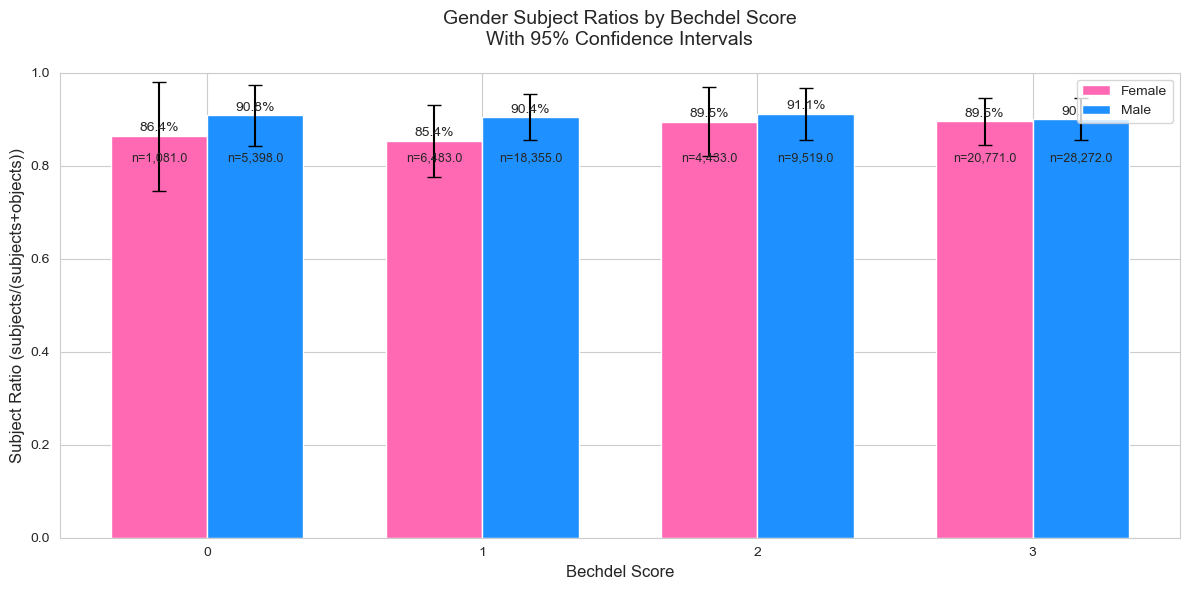

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Calculate confidence intervals (assuming binomial distribution)
def wilson_ci(p, n, z=1.96):
    denominator = 1 + z**2/n
    centre_adjusted_probability = p + z*z/(2*n)
    adjusted_standard_deviation = np.sqrt((p*(1 - p) + z*z/(4*n))/np.sqrt(n))
    
    lower_bound = (centre_adjusted_probability - z*adjusted_standard_deviation)/denominator
    upper_bound = (centre_adjusted_probability + z*adjusted_standard_deviation)/denominator
    return lower_bound, upper_bound

# Add CI to dataframe
results_df['female_ci_lower'], results_df['female_ci_upper'] = zip(*results_df.apply(
    lambda row: wilson_ci(row['female_ratio'], row['female_subjects']+row['female_objects']), axis=1))
results_df['male_ci_lower'], results_df['male_ci_upper'] = zip(*results_df.apply(
    lambda row: wilson_ci(row['male_ratio'], row['male_subjects']+row['male_objects']), axis=1))

# Create plot
bar_width = 0.35
index = np.arange(len(results_df))

# Female ratios
plt.bar(index - bar_width/2, results_df['female_ratio'], bar_width,
        yerr=[results_df['female_ratio']-results_df['female_ci_lower'], 
             results_df['female_ci_upper']-results_df['female_ratio']],
        label='Female', color='#FF69B4', capsize=5)

# Male ratios
plt.bar(index + bar_width/2, results_df['male_ratio'], bar_width,
        yerr=[results_df['male_ratio']-results_df['male_ci_lower'], 
             results_df['male_ci_upper']-results_df['male_ratio']],
        label='Male', color='#1E90FF', capsize=5)

# Formatting
plt.xlabel('Bechdel Score', fontsize=12)
plt.ylabel('Subject Ratio (subjects/(subjects+objects))', fontsize=12)
plt.title('Gender Subject Ratios by Bechdel Score\nWith 95% Confidence Intervals', fontsize=14, pad=20)
plt.xticks(index, results_df['bechdel_score'])
plt.ylim(0, 1)
plt.legend(loc='upper right')

# Add value labels
for i, score in enumerate(results_df['bechdel_score']):
    plt.text(i - bar_width/2, results_df.loc[i, 'female_ratio'] + 0.01, 
             f"{results_df.loc[i, 'female_ratio']:.1%}", ha='center')
    plt.text(i + bar_width/2, results_df.loc[i, 'male_ratio'] + 0.01, 
             f"{results_df.loc[i, 'male_ratio']:.1%}", ha='center')

# Add sample size annotations
for i, score in enumerate(results_df['bechdel_score']):
    plt.text(i - bar_width/2, 0.81, 
             f"n={(results_df.loc[i, 'female_subjects']+results_df.loc[i, 'female_objects']):,}", 
             ha='center', fontsize=9)
    plt.text(i + bar_width/2, 0.81, 
             f"n={(results_df.loc[i, 'male_subjects']+results_df.loc[i, 'male_objects']):,}", 
             ha='center', fontsize=9)

plt.tight_layout()
plt.show()